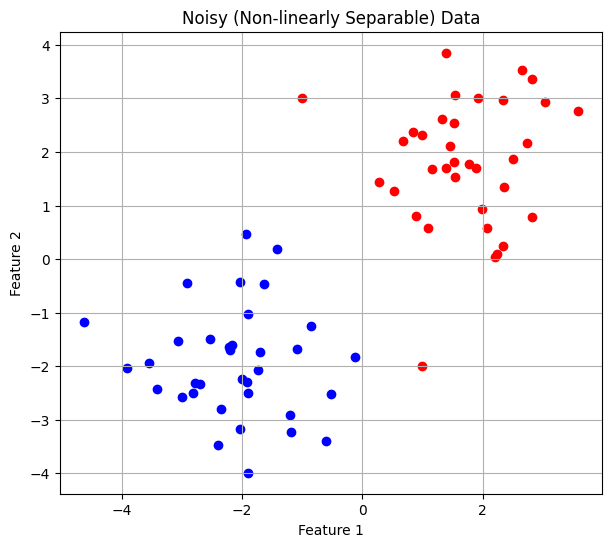

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from cvxopt import matrix, solvers

# --- Generate Non-perfectly Separable Dataset ---
np.random.seed(42)
X_pos = np.random.randn(35, 2) + [2, 2]
X_neg = np.random.randn(35, 2) + [-2, -2]
X = np.vstack((X_pos, X_neg))
y = np.hstack((np.ones(35), -1 * np.ones(35)))

# Add noise to make it non-separable
X[10] = [-1, 3]
X[25] = [1, -2]

# --- Plot Function ---
def plot_data(X, y):
    plt.figure(figsize=(7, 6))
    for i in range(len(y)):
        color = 'r' if y[i] == 1 else 'b'
        plt.scatter(X[i][0], X[i][1], color=color)
    plt.title("Noisy (Non-linearly Separable) Data")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.grid(True)
    plt.show()

plot_data(X, y)

Epoch 0: w2 = 0.0350
Epoch 100: w2 = 0.8739
Epoch 200: w2 = 1.1607
Epoch 300: w2 = 1.3452
Epoch 400: w2 = 1.5490
Epoch 500: w2 = 1.7652
Epoch 600: w2 = 1.9973
Epoch 700: w2 = 2.2505
Epoch 800: w2 = 2.5142
Epoch 900: w2 = 2.7907


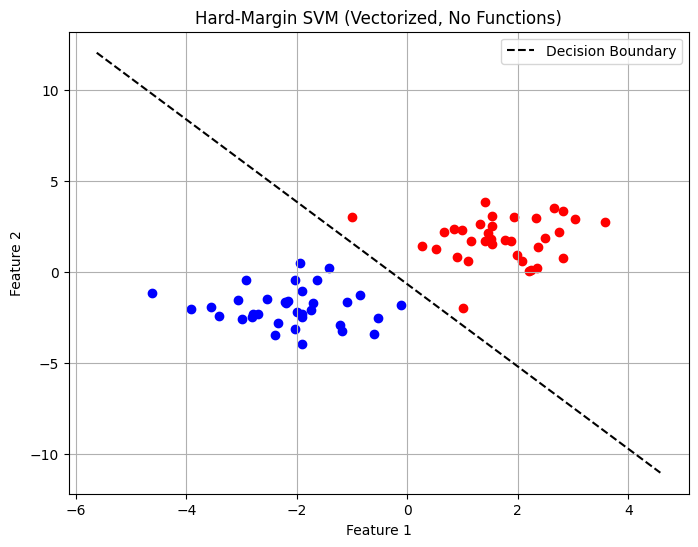

In [9]:
m = X.shape[0]
w = np.zeros(X.shape[1])
b = 0
lr = 0.001
epochs = 1000
for epoch in range(epochs):
    y_pred = y*(X@w.T+b)
    constrant = y_pred<1
    x_c = X[constrant]
    y_c = y[constrant]
    if len(y_c)>0:
        dw = np.sum(y_c[:, np.newaxis] * x_c, axis=0)
        db = np.sum(y_c)
        w += lr*dw
        b += lr*db
    if epoch % 100 == 0:
        print(f"Epoch {epoch}: w2 = {np.dot(w, w):.4f}")


plt.figure(figsize=(8, 6))
for i in range(len(y)):
    color = 'r' if y[i] == 1 else 'b'
    plt.scatter(X[i][0], X[i][1], color=color)

x_vals = np.linspace(np.min(X[:, 0]) - 1, np.max(X[:, 0]) + 1, 100)
y_vals = -(w[0] * x_vals + b) / w[1]
plt.plot(x_vals, y_vals, 'k--', label='Decision Boundary')

plt.title("Hard-Margin SVM (Vectorized, No Functions)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.legend()
plt.show()

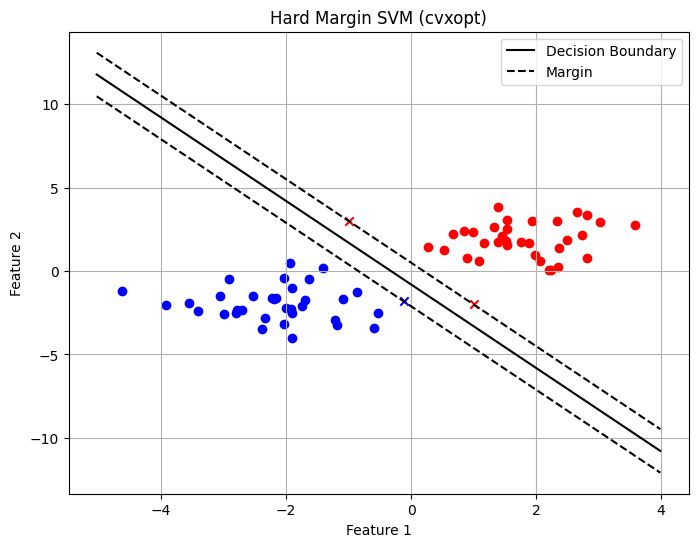

In [10]:
def hard_margin_svm(X, y):
    n_samples = X.shape[0]
    K = np.dot(X, X.T)

    P = matrix(np.outer(y, y) * K)
    q = matrix(-np.ones(n_samples))

    G = matrix(-np.eye(n_samples))
    h = matrix(np.zeros(n_samples))

    A = matrix(y.reshape(1, -1).astype(float))
    b = matrix(0.0)

    solvers.options['show_progress'] = False
    sol = solvers.qp(P, q, G, h, A, b)
    alpha = np.ravel(sol['x'])

    sv = alpha > 1e-5
    w = np.sum(alpha[sv, None] * y[sv, None] * X[sv], axis=0)
    b = np.mean(y[sv] - X[sv] @ w)

    return w, b, alpha, sv

w, b, alpha, sv = hard_margin_svm(X, y)
def plot_decision_boundary(X, y, w, b, sv):
    plt.figure(figsize=(8, 6))
    for i in range(len(y)):
        plt.scatter(X[i, 0], X[i, 1], color='r' if y[i] == 1 else 'b', marker='x' if sv[i] else 'o')

    ax = plt.gca()
    xlim = ax.get_xlim()
    xx = np.linspace(xlim[0], xlim[1], 200)
    yy = -(w[0] * xx + b) / w[1]
    margin = 1 / np.linalg.norm(w)
    yy_up = yy + margin * np.sqrt(1 + (w[0] / w[1])**2)
    yy_down = yy - margin * np.sqrt(1 + (w[0] / w[1])**2)

    plt.plot(xx, yy, 'k-', label='Decision Boundary')
    plt.plot(xx, yy_up, 'k--', label='Margin')
    plt.plot(xx, yy_down, 'k--')
    plt.legend()
    plt.title("Hard Margin SVM (cvxopt)")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.grid(True)
    plt.show()

plot_decision_boundary(X, y, w, b, sv)

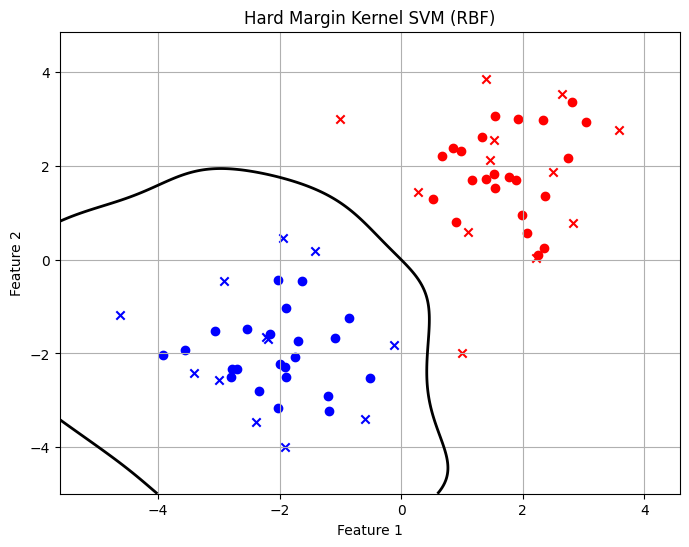

In [ ]:
# Hard margin with kernel trick 
import numpy as np
import matplotlib.pyplot as plt
from cvxopt import matrix, solvers

# =========================
# Generate non-separable data
# =========================
np.random.seed(42)
X_pos = np.random.randn(35, 2) + [2, 2]
X_neg = np.random.randn(35, 2) + [-2, -2]
X = np.vstack((X_pos, X_neg))
y = np.hstack((np.ones(35), -1 * np.ones(35)))

# Inject noise
X[10] = [-1, 3]
X[25] = [1, -2]

def linear_kernel(X1, X2, gamma=None):
    return np.dot(X1, X2.T)

def rbf_kernel(X1, X2, gamma=0.5):
    sq_dists = (
        np.sum(X1**2, axis=1).reshape(-1, 1)
        + np.sum(X2**2, axis=1)
        - 2 * np.dot(X1, X2.T)
    )
    return np.exp(-gamma * sq_dists)

def hard_margin_kernel_svm(X, y, kernel, gamma=0.5):
    n_samples = X.shape[0]
    K = kernel(X, X, gamma)
    P = matrix(np.outer(y, y) * K)
    q = matrix(-np.ones(n_samples))
    G = matrix(-np.eye(n_samples))
    h = matrix(np.zeros(n_samples))
    A = matrix(y.reshape(1, -1))
    b = matrix(0.0)

    solvers.options['show_progress'] = False
    sol = solvers.qp(P, q, G, h, A, b)

    alpha = np.ravel(sol['x'])
    sv = alpha > 1e-5

    b = np.mean([
        y[i] - np.sum(alpha[sv] * y[sv] * K[i, sv]) for i in np.where(sv)[0]])

    return alpha, sv, b

def decision_function(X_train, y_train, alpha, b, kernel, X_test, gamma=0.5):
    K = kernel(X_test, X_train, gamma)
    return np.dot(K, alpha * y_train) + b

def plot_kernel_boundary(X, y, alpha, sv, b, kernel, gamma=0.5):
    plt.figure(figsize=(8, 6))
    for i in range(len(y)):
        plt.scatter(X[i, 0], X[i, 1], color='r' if y[i] == 1 else 'b', marker='x' if sv[i] else 'o')

    xx, yy = np.meshgrid(
        np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 300),
        np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = decision_function(X, y, alpha, b, kernel, grid, gamma)
    Z = Z.reshape(xx.shape)

    plt.contour(xx, yy, Z, levels=[0], colors='k', linewidths=2)

    plt.title("Hard Margin Kernel SVM (RBF)")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.grid(True)
    plt.show()

alpha, sv, b = hard_margin_kernel_svm(
    X, y,
    kernel=rbf_kernel,
    gamma=0.5
)

plot_kernel_boundary(
    X, y,
    alpha, sv, b,
    kernel=rbf_kernel,
    gamma=0.5
)
